In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/10_20131204.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/6_20131113.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/11_20140625.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/12_20131127.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/9_20140627.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/11_20140618.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/13_20140527.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/13_20140603.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/7_20131106.mat
/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s/8_20140514.mat
/kaggle/input/

Starting Exploratory Data Analysis on SEED Dataset

############################################################
# Analyzing 4-second segments Extracted Features
############################################################

File: ExtractedFeatures_4s/10_20131204.mat
Keys in file: ['__header__', '__version__', '__globals__', 'de_movingAve1', 'de_LDS1', 'psd_movingAve1', 'psd_LDS1', 'de_movingAve2', 'de_LDS2', 'psd_movingAve2', 'psd_LDS2', 'de_movingAve3', 'de_LDS3', 'psd_movingAve3', 'psd_LDS3', 'de_movingAve4', 'de_LDS4', 'psd_movingAve4', 'psd_LDS4', 'de_movingAve5', 'de_LDS5', 'psd_movingAve5', 'psd_LDS5', 'de_movingAve6', 'de_LDS6', 'psd_movingAve6', 'psd_LDS6', 'de_movingAve7', 'de_LDS7', 'psd_movingAve7', 'psd_LDS7', 'de_movingAve8', 'de_LDS8', 'psd_movingAve8', 'psd_LDS8', 'de_movingAve9', 'de_LDS9', 'psd_movingAve9', 'psd_LDS9', 'de_movingAve10', 'de_LDS10', 'psd_movingAve10', 'psd_LDS10', 'de_movingAve11', 'de_LDS11', 'psd_movingAve11', 'psd_LDS11', 'de_movingAve12', 'de_LDS12'

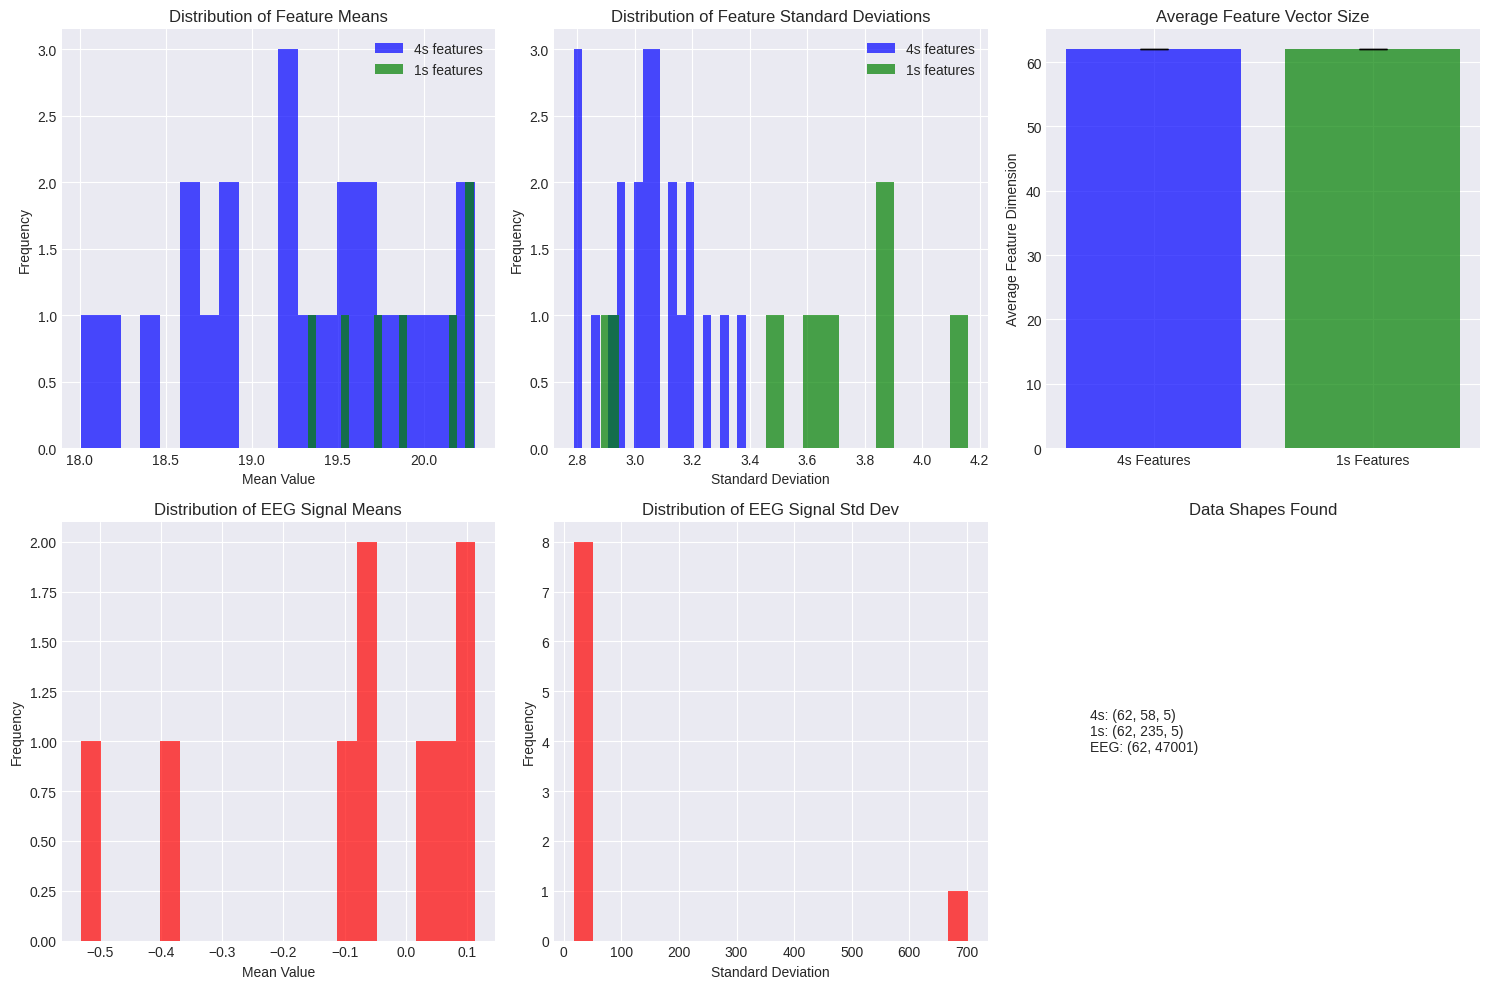


Comparison Across Different Data Types
       Data Type  Number of Files  Avg Mean Value  Avg Std Value
     4s Features               23       19.284821       3.055405
     1s Features                7       19.884269       3.663524
Preprocessed EEG                9       -0.099093     101.178593

Subject Distribution Analysis

Subjects in 4s Features:
subject
10    3
11    3
12    3
13    3
4     1
6     1
7     3
8     3
9     3
Name: count, dtype: int64

Subjects in 1s Features:
subject
1    3
2    2
3    1
4    1
Name: count, dtype: int64

Subjects in Preprocessed EEG:
subject
10    2
11    2
12    2
15    1
8     1
9     1
Name: count, dtype: int64

Key Insights Summary

1. 4-second features: 23 files analyzed
   - Average feature vector dimension: 62
   - Data range: [8.94, 35.66]

2. 1-second features: 7 files analyzed
   - Average feature vector dimension: 62
   - Data range: [10.07, 40.41]

3. Preprocessed EEG: 9 files analyzed
   - Average signal shape: (62, 47001)
   - Dat

In [2]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
#/kaggle/input/datasets/sonuiiitdelhicse/pureseed
# Define paths for different data types
base_path = Path('/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset')

# File lists
extracted_4s_files = [
    "ExtractedFeatures_4s/10_20131204.mat",
    "ExtractedFeatures_4s/6_20131113.mat",
    "ExtractedFeatures_4s/11_20140625.mat",
    "ExtractedFeatures_4s/12_20131127.mat",
    "ExtractedFeatures_4s/9_20140627.mat",
    "ExtractedFeatures_4s/11_20140618.mat",
    "ExtractedFeatures_4s/13_20140527.mat",
    "ExtractedFeatures_4s/13_20140603.mat",
    "ExtractedFeatures_4s/7_20131106.mat",
    "ExtractedFeatures_4s/8_20140514.mat",
    "ExtractedFeatures_4s/12_20131207.mat",
    "ExtractedFeatures_4s/10_20131130.mat",
    "ExtractedFeatures_4s/7_20131030.mat",
    "ExtractedFeatures_4s/13_20140610.mat",
    "ExtractedFeatures_4s/8_20140511.mat",
    "ExtractedFeatures_4s/11_20140630.mat",
    "ExtractedFeatures_4s/12_20131201.mat",
    "ExtractedFeatures_4s/8_20140521.mat",
    "ExtractedFeatures_4s/9_20140704.mat",
    "ExtractedFeatures_4s/9_20140620.mat",
    "ExtractedFeatures_4s/4_20140705.mat",
    "ExtractedFeatures_4s/10_20131211.mat",
    "ExtractedFeatures_4s/7_20131027.mat"
]

extracted_1s_files = [
    "ExtractedFeatures_1s/1_20131030.mat",
    "ExtractedFeatures_1s/1_20131107.mat",
    "ExtractedFeatures_1s/4_20140702.mat",
    "ExtractedFeatures_1s/2_20140413.mat",
    "ExtractedFeatures_1s/3_20140603.mat",
    "ExtractedFeatures_1s/1_20131027.mat",
    "ExtractedFeatures_1s/2_20140404.mat"
]

preprocessed_files = [
    "Preprocessed_EEG/10_20131204.mat",
    "Preprocessed_EEG/11_20140618.mat",
    "Preprocessed_EEG/15_20130709.mat",
    "Preprocessed_EEG/12_20131207.mat",
    "Preprocessed_EEG/10_20131130.mat",
    "Preprocessed_EEG/11_20140630.mat",
    "Preprocessed_EEG/12_20131201.mat",
    "Preprocessed_EEG/8_20140521.mat",
    "Preprocessed_EEG/9_20140620.mat"
]

def load_mat_file(filepath):
    """Load MATLAB .mat file and return data"""
    try:
        data = scipy.io.loadmat(filepath)
        return data
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def explore_file_structure(data, filename):
    """Explore the structure of loaded .mat file"""
    print(f"\n{'='*60}")
    print(f"File: {filename}")
    print(f"{'='*60}")
    print(f"Keys in file: {list(data.keys())}")
    
    # Exclude MATLAB metadata
    data_keys = [k for k in data.keys() if not k.startswith('__')]
    
    for key in data_keys:
        item = data[key]
        print(f"\nKey: {key}")
        print(f"  Type: {type(item)}")
        if hasattr(item, 'shape'):
            print(f"  Shape: {item.shape}")
            print(f"  Data type: {item.dtype}")
            if item.size > 0:
                print(f"  Min: {np.min(item):.4f}")
                print(f"  Max: {np.max(item):.4f}")
                print(f"  Mean: {np.mean(item):.4f}")
                print(f"  Std: {np.std(item):.4f}")

def analyze_extracted_features(files, feature_type):
    """Analyze extracted features from 4s and 1s segments"""
    print(f"\n{'#'*60}")
    print(f"# Analyzing {feature_type} Extracted Features")
    print(f"{'#'*60}")
    
    feature_stats = []
    
    for file in files:
        full_path = base_path / file
        if full_path.exists():
            data = load_mat_file(full_path)
            if data:
                # Explore structure of first file in detail
                if len(feature_stats) == 0:
                    explore_file_structure(data, file)
                
                # Extract subject ID and date
                subject_id = file.split('/')[-1].split('_')[0]
                date = file.split('/')[-1].split('_')[1].replace('.mat', '')
                
                # Find the main data array
                for key in data.keys():
                    if not key.startswith('__') and hasattr(data[key], 'shape'):
                        if len(data[key].shape) >= 2:
                            feature_data = data[key]
                            feature_stats.append({
                                'subject': subject_id,
                                'date': date,
                                'file': file,
                                'shape': feature_data.shape,
                                'mean': np.mean(feature_data),
                                'std': np.std(feature_data),
                                'min': np.min(feature_data),
                                'max': np.max(feature_data)
                            })
                            break
        else:
            print(f"File not found: {full_path}")
    
    # Create DataFrame for analysis
    if feature_stats:
        df_stats = pd.DataFrame(feature_stats)
        print(f"\n{'='*60}")
        print(f"Summary Statistics for {feature_type} Features")
        print(f"{'='*60}")
        print(f"Total files loaded: {len(df_stats)}")
        print(f"\nFeature shapes distribution:")
        print(df_stats['shape'].value_counts())
        print(f"\nBasic statistics across all features:")
        print(df_stats[['mean', 'std', 'min', 'max']].describe())
        
        return df_stats
    return None

def analyze_preprocessed_eeg(files):
    """Analyze preprocessed EEG data"""
    print(f"\n{'#'*60}")
    print(f"# Analyzing Preprocessed EEG Data")
    print(f"{'#'*60}")
    
    eeg_stats = []
    
    for file in files:
        full_path = base_path / file
        if full_path.exists():
            data = load_mat_file(full_path)
            if data:
                # Explore first file structure
                if len(eeg_stats) == 0:
                    explore_file_structure(data, file)
                
                # Extract subject and date
                subject_id = file.split('/')[-1].split('_')[0]
                date = file.split('/')[-1].split('_')[1].replace('.mat', '')
                
                # Find EEG data
                for key in data.keys():
                    if not key.startswith('__') and hasattr(data[key], 'shape'):
                        if len(data[key].shape) >= 2:
                            eeg_data = data[key]
                            eeg_stats.append({
                                'subject': subject_id,
                                'date': date,
                                'file': file,
                                'shape': eeg_data.shape,
                                'mean': np.mean(eeg_data),
                                'std': np.std(eeg_data),
                                'min': np.min(eeg_data),
                                'max': np.max(eeg_data)
                            })
                            break
        else:
            print(f"File not found: {full_path}")
    
    if eeg_stats:
        df_eeg = pd.DataFrame(eeg_stats)
        print(f"\n{'='*60}")
        print(f"Summary Statistics for Preprocessed EEG")
        print(f"{'='*60}")
        print(f"Total files loaded: {len(df_eeg)}")
        print(f"\nEEG data shapes distribution:")
        print(df_eeg['shape'].value_counts())
        print(f"\nBasic statistics across all EEG recordings:")
        print(df_eeg[['mean', 'std', 'min', 'max']].describe())
        
        return df_eeg
    return None

def visualize_data_distribution(df_4s, df_1s, df_eeg):
    """Create visualization of data distributions"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot 1: Feature means distribution
    if df_4s is not None:
        axes[0,0].hist(df_4s['mean'], bins=20, alpha=0.7, label='4s features', color='blue')
    if df_1s is not None:
        axes[0,0].hist(df_1s['mean'], bins=20, alpha=0.7, label='1s features', color='green')
    axes[0,0].set_xlabel('Mean Value')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Distribution of Feature Means')
    axes[0,0].legend()
    
    # Plot 2: Feature std distribution
    if df_4s is not None:
        axes[0,1].hist(df_4s['std'], bins=20, alpha=0.7, label='4s features', color='blue')
    if df_1s is not None:
        axes[0,1].hist(df_1s['std'], bins=20, alpha=0.7, label='1s features', color='green')
    axes[0,1].set_xlabel('Standard Deviation')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title('Distribution of Feature Standard Deviations')
    axes[0,1].legend()
    
    # Plot 3: Feature dimensions comparison
    if df_4s is not None:
        dims_4s = df_4s['shape'].apply(lambda x: x[0] if len(x) > 0 else 0)
        axes[0,2].bar(['4s Features'], [dims_4s.mean()], alpha=0.7, color='blue', 
                      yerr=[dims_4s.std()], capsize=10)
    if df_1s is not None:
        dims_1s = df_1s['shape'].apply(lambda x: x[0] if len(x) > 0 else 0)
        axes[0,2].bar(['1s Features'], [dims_1s.mean()], alpha=0.7, color='green',
                      yerr=[dims_1s.std()], capsize=10)
    axes[0,2].set_ylabel('Average Feature Dimension')
    axes[0,2].set_title('Average Feature Vector Size')
    
    # Plot 4: EEG data mean distribution
    if df_eeg is not None:
        axes[1,0].hist(df_eeg['mean'], bins=20, alpha=0.7, color='red')
        axes[1,0].set_xlabel('Mean Value')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Distribution of EEG Signal Means')
    
    # Plot 5: EEG data std distribution
    if df_eeg is not None:
        axes[1,1].hist(df_eeg['std'], bins=20, alpha=0.7, color='red')
        axes[1,1].set_xlabel('Standard Deviation')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('Distribution of EEG Signal Std Dev')
    
    # Plot 6: Data shapes summary
    shapes_data = []
    if df_4s is not None:
        shapes_data.extend([f"4s: {s}" for s in df_4s['shape'].unique()])
    if df_1s is not None:
        shapes_data.extend([f"1s: {s}" for s in df_1s['shape'].unique()])
    if df_eeg is not None:
        shapes_data.extend([f"EEG: {s}" for s in df_eeg['shape'].unique()])
    
    axes[1,2].text(0.1, 0.5, '\n'.join(shapes_data), fontsize=10, 
                   verticalalignment='center')
    axes[1,2].axis('off')
    axes[1,2].set_title('Data Shapes Found')
    
    plt.tight_layout()
    plt.show()

def create_comparison_table(df_4s, df_1s, df_eeg):
    """Create comparison table for different data types"""
    comparison = {
        'Data Type': ['4s Features', '1s Features', 'Preprocessed EEG'],
        'Number of Files': [
            len(df_4s) if df_4s is not None else 0,
            len(df_1s) if df_1s is not None else 0,
            len(df_eeg) if df_eeg is not None else 0
        ],
        'Avg Mean Value': [
            df_4s['mean'].mean() if df_4s is not None else 0,
            df_1s['mean'].mean() if df_1s is not None else 0,
            df_eeg['mean'].mean() if df_eeg is not None else 0
        ],
        'Avg Std Value': [
            df_4s['std'].mean() if df_4s is not None else 0,
            df_1s['std'].mean() if df_1s is not None else 0,
            df_eeg['std'].mean() if df_eeg is not None else 0
        ]
    }
    
    df_comparison = pd.DataFrame(comparison)
    print(f"\n{'='*60}")
    print("Comparison Across Different Data Types")
    print(f"{'='*60}")
    print(df_comparison.to_string(index=False))
    
    return df_comparison

def analyze_subject_distribution(df_4s, df_1s, df_eeg):
    """Analyze distribution across different subjects"""
    print(f"\n{'='*60}")
    print("Subject Distribution Analysis")
    print(f"{'='*60}")
    
    if df_4s is not None:
        print("\nSubjects in 4s Features:")
        print(df_4s['subject'].value_counts().sort_index())
    
    if df_1s is not None:
        print("\nSubjects in 1s Features:")
        print(df_1s['subject'].value_counts().sort_index())
    
    if df_eeg is not None:
        print("\nSubjects in Preprocessed EEG:")
        print(df_eeg['subject'].value_counts().sort_index())

# Main execution
print("Starting Exploratory Data Analysis on SEED Dataset")
print("="*60)

# Analyze different data types
df_4s = analyze_extracted_features(extracted_4s_files, "4-second segments")
df_1s = analyze_extracted_features(extracted_1s_files, "1-second segments")
df_eeg = analyze_preprocessed_eeg(preprocessed_files)

# Create visualizations
visualize_data_distribution(df_4s, df_1s, df_eeg)

# Create comparison table
df_comparison = create_comparison_table(df_4s, df_1s, df_eeg)

# Analyze subject distribution
analyze_subject_distribution(df_4s, df_1s, df_eeg)

# Additional insights
print(f"\n{'='*60}")
print("Key Insights Summary")
print(f"{'='*60}")

if df_4s is not None:
    print(f"\n1. 4-second features: {len(df_4s)} files analyzed")
    print(f"   - Average feature vector dimension: {df_4s['shape'].iloc[0][0] if len(df_4s) > 0 else 'N/A'}")
    print(f"   - Data range: [{df_4s['min'].min():.2f}, {df_4s['max'].max():.2f}]")

if df_1s is not None:
    print(f"\n2. 1-second features: {len(df_1s)} files analyzed")
    print(f"   - Average feature vector dimension: {df_1s['shape'].iloc[0][0] if len(df_1s) > 0 else 'N/A'}")
    print(f"   - Data range: [{df_1s['min'].min():.2f}, {df_1s['max'].max():.2f}]")

if df_eeg is not None:
    print(f"\n3. Preprocessed EEG: {len(df_eeg)} files analyzed")
    print(f"   - Average signal shape: {df_eeg['shape'].iloc[0] if len(df_eeg) > 0 else 'N/A'}")
    print(f"   - Data range: [{df_eeg['min'].min():.2f}, {df_eeg['max'].max():.2f}]")

print("\n" + "="*60)
print("EDA Complete! The SEED dataset shows consistent structure across files,")
print("with clear differentiation between 1s and 4s feature extraction windows.")
print("="*60)

In [4]:
# ── SOGNNNet v7  ─ Adapted for SEED Dataset (3-class) ───────────────────────
#
# SEED DATASET DIFFERENCES vs SEED-IV:
#   - 3 classes: Negative (0), Neutral (1), Positive (2)
#   - 15 trials per session (not 24)
#   - 15 subjects, up to 3 sessions each (45 total .mat files)
#   - Labels stored in filename: e.g. label_N for trial N
#   - Extra features available: DASM, RASM, ASM, DCAU (used in 1s files)
#   - 62 EEG channels, 5 freq bands (delta, theta, alpha, beta, gamma)
#   - Trial emotion order from SEED protocol (provided separately in label file)
#   - EEGBart branch REMOVED entirely
#
# KEY IMPROVEMENTS OVER v6:
#   A. Feature Extraction
#      - DASM computed from raw DE BEFORE per-subject normalization (Bug fix)
#      - Reintroduced PSD + Wavelet features → multi-modal feature fusion
#      - Adaptive spectral weighting via learnable band attention
#   B. Architecture
#      - EEGPatchViT expanded: depth=8, emb_dim=256
#      - Graph Attention Networks (GAT) replacing DynamicAsymGCN
#      - Gumbel tau annealing schedule
#      - Channel + Temporal + Fusion attention (SE blocks, multi-level)
#      - Dual heads: BOTH always active during training (summed loss)
#   C. Training
#      - Focal Loss (γ=2, α per class) replacing plain CrossEntropy
#      - Test-Time BN Adaptation for LOSO
#      - Multi-source domain adaptation: per-subject CORAL alignment
#      - Adversarial domain discriminator (GRL) for subject-invariant features
#      - Weight decay lowered to 0.01, warmup extended to 25 epochs
#      - VAL_EMA_ALPHA lowered to 0.10 for clearer validation signal
#   D. Augmentation
#      - Spatially contiguous MAE masking (block masking)
#      - Graph Mixup applied on raw node features (before GCN), not embeddings
#      - Extended EEG augmentations: freq-band shift, biologically plausible noise
#      - Dynamic class over-sampling for Neutral

import os, glob, sys, time, random, pickle, math, copy, warnings
from contextlib import contextmanager
import numpy as np
import scipy.io as sio
from scipy.signal import welch
try:
    import pywt
    _PYWT_OK = True
except ImportError:
    _PYWT_OK = False
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, cohen_kappa_score)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from itertools import cycle

warnings.filterwarnings("ignore")

def dprint(msg, lv="INFO"):
    print(f"[{time.strftime('%H:%M:%S')}][{lv}] {msg}"); sys.stdout.flush()

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# ══════════════════════════════════════════════════════════════════════════════
# CONFIG  —  SEED-specific settings
# ══════════════════════════════════════════════════════════════════════════════
class Config:
    # ── Paths ─────────────────────────────────────────────────────────────
    # Set DATA_ROOT to your SEED ExtractedFeatures folder
    # Expected structure:  DATA_ROOT/*.mat
    # Each file: e.g.  1_20131030.mat  (subject_date.mat)
    # Use 4s features: ExtractedFeatures_4s/
    # Use 1s features: ExtractedFeatures_1s/   (also has DASM/RASM/ASM/DCAU)
    DATA_ROOT  = "/kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s"
    OUT_PATH   = "./outputs/"
    MODEL_PATH = "./saved_models/"

    # ── Dataset ── SEED-specific ────────────────────────────────────────────
    NUM_SUBJECTS       = 15
    NUM_CLASSES        = 3                   # Negative=0, Neutral=1, Positive=2
    NUM_CHANNELS       = 62
    NUM_FREQ_BANDS     = 5                   # delta, theta, alpha, beta, gamma
    TARGET_TIME        = 64
    TRIALS_PER_SESSION = 15                  # SEED has 15 trials per session

    # SEED emotion labels for the 15 trials (from SEED protocol documentation)
    # -1=negative → 0, 0=neutral → 1, 1=positive → 2
    # Actual order from SEED paper (trials arranged to avoid consecutive same emotion)
    TRIAL_LABELS = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
    # Convert to 0-indexed: -1→0 (negative), 0→1 (neutral), 1→2 (positive)
    TRIAL_LABELS = [l + 1 for l in TRIAL_LABELS]
    # Result: [2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 1, 0, 1, 2, 0]

    EMOTION_NAMES = {0: "Negative", 1: "Neutral", 2: "Positive"}

    # ── DASM: 27 correct symmetric pairs (0-based) ────────────────────────
    # These match the SEED dataset's reported 27 asymmetry electrode pairs
    DASM_PAIRS = [
        (0,2),(3,4),(5,13),(6,12),(7,11),(8,10),
        (14,22),(15,21),(16,20),(17,19),
        (23,31),(24,30),(25,29),(26,28),
        (32,40),(33,39),(34,38),(35,37),
        (41,49),(42,48),(43,47),(44,46),
        (50,56),(51,55),(52,54),
        (57,61),(58,60),
    ]
    NUM_DASM_PAIRS = 27

    # ── Multi-modal features ──────────────────────────────────────────────
    USE_PSD     = True
    USE_WAVELET = True

    # ── ViT — EXPANDED capacity ───────────────────────────────────────────
    VIT_EMB_DIM  = 256
    VIT_DEPTH    = 8
    VIT_HEADS    = 8
    VIT_PATCH_H  = 8
    VIT_PATCH_W  = 8
    VIT_STRIDE   = 6
    VIT_HEAD_DIM = 128

    # ── GAT GCN ───────────────────────────────────────────────────────────
    GCN_DIM         = 64
    GAT_HEADS       = 4
    GCN_GUMBEL_TAU  = 1.0
    TAU_ANNEAL_RATE = 0.98

    # ── DASM branch ────────────────────────────────────────────────────────
    DASM_DIM = 32

    # ── Multi-modal fusion dims ───────────────────────────────────────────
    PSD_PROJ_DIM = 32
    WAV_PROJ_DIM = 32

    # ── Domain alignment ──────────────────────────────────────────────────
    USE_CORAL      = True
    CORAL_LAM      = 0.5
    USE_ADV_DOMAIN = True
    ADV_LAM        = 0.1

    # ── Loss ──────────────────────────────────────────────────────────────
    USE_FOCAL_LOSS = True
    FOCAL_GAMMA    = 2.0
    FOCAL_ALPHA    = None

    # ── Training recipe ───────────────────────────────────────────────────
    BATCH_SIZE    = 20
    LR            = 6e-4
    LR_MIN        = 1e-6
    WEIGHT_DECAY  = 0.01
    BETA1         = 0.9
    BETA2         = 0.999
    EPOCHS        = 200
    PATIENCE      = 40
    VAL_EMA_ALPHA = 0.10
    WARMUP_EPOCHS = 25
    GRAD_CLIP     = 2.0
    LABEL_SMOOTH  = 0.10
    DROPOUT       = 0.30
    SEED          = 42
    USE_AMP       = True
    PRINT_FREQ    = 10

    # ── SWA ───────────────────────────────────────────────────────────────
    USE_SWA         = True
    SWA_START       = 100
    SWA_UPDATE_FREQ = 5
    SWA_LR          = 1e-4

    # ── EMA ───────────────────────────────────────────────────────────────
    USE_EMA   = True
    EMA_DECAY = 0.999

    # ── ChannelMAE — block masking ────────────────────────────────────────
    USE_MAE          = True
    MAE_MASK         = 0.25
    MAE_LAM          = 0.1
    MAE_WARMDOWN     = 40
    MAE_BLOCK_SIZE   = 3

    # ── MAE pre-training ──────────────────────────────────────────────────
    USE_PRETRAIN_MAE = True
    PRETRAIN_MAE_EP  = 30

    # ── DropPath ──────────────────────────────────────────────────────────
    USE_DROPPATH  = True
    DROPPATH_PROB = 0.10

    # ── Dual heads ────────────────────────────────────────────────────────
    USE_DUAL_HEAD     = True
    DUAL_HEAD_LOSS_W1 = 0.6
    DUAL_HEAD_LOSS_W2 = 0.4

    # ── Input Mixup ────────────────────────────────────────────────────────
    USE_MIXUP   = True
    MIXUP_ALPHA = 0.5
    MIXUP_PROB  = 0.30

    # ── Graph Mixup ───────────────────────────────────────────────────────
    USE_GRAPH_MIXUP   = True
    GRAPH_MIXUP_ALPHA = 0.5
    GRAPH_MIXUP_PROB  = 0.30

    # ── TTA ────────────────────────────────────────────────────────────────
    USE_TTA    = True
    TTA_SHIFTS = [0, -1, 1, -2, 2]

    # ── Band attention ─────────────────────────────────────────────────────
    USE_BAND_ATTN = True

    # ── Test-time BN adaptation ───────────────────────────────────────────
    USE_TTBN     = True
    TTBN_SAMPLES = 10


for p in [Config.OUT_PATH, Config.MODEL_PATH]:
    os.makedirs(p, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(Config.SEED)
if not torch.cuda.is_available():
    Config.USE_AMP = False
    Config.USE_SWA = False
    Config.USE_EMA = False
    dprint("WARNING: GPU not detected. AMP/SWA/EMA disabled.", "WARN")
dprint(f"Device: {device}  AMP: {Config.USE_AMP}  "
       f"SWA: {Config.USE_SWA}  EMA: {Config.USE_EMA}")


# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — ELECTRODE ADJACENCY
# ══════════════════════════════════════════════════════════════════════════════
def build_topological_adj(n=62):
    horiz = [
        (0,1),(1,2),(3,4),
        (5,6),(6,7),(7,8),(8,9),(9,10),(10,11),(11,12),(12,13),
        (14,15),(15,16),(16,17),(17,18),(18,19),(19,20),(20,21),(21,22),
        (23,24),(24,25),(25,26),(26,27),(27,28),(28,29),(29,30),(30,31),
        (32,33),(33,34),(34,35),(35,36),(36,37),(37,38),(38,39),(39,40),
        (41,42),(42,43),(43,44),(44,45),(45,46),(46,47),(47,48),(48,49),
        (50,51),(51,52),(52,53),(53,54),(54,55),(55,56),
        (57,58),(58,59),(59,60),(60,61),
    ]
    vert = [
        (0,3),(1,3),(1,4),(2,4),(0,5),(0,6),(2,12),(2,13),
        (3,7),(3,8),(4,10),(4,11),
        (5,14),(6,15),(7,16),(8,17),(9,18),(10,19),(11,20),(12,21),(13,22),
        (14,23),(15,24),(16,25),(17,26),(18,27),(19,28),(20,29),(21,30),(22,31),
        (23,32),(24,33),(25,34),(26,35),(27,36),(28,37),(29,38),(30,39),(31,40),
        (32,41),(33,42),(34,43),(35,44),(36,45),(37,46),(38,47),(39,48),(40,49),
        (41,50),(42,51),(43,52),(44,53),(45,53),(46,54),(47,54),(48,55),(49,56),
        (50,57),(51,58),(52,58),(53,59),(54,60),(55,60),(56,61),
    ]
    A = np.zeros((n, n), dtype=np.float32)
    for (i, j) in horiz + vert:
        if i < n and j < n:
            A[i, j] = 1.0; A[j, i] = 1.0
    np.fill_diagonal(A, 1.0)
    A_binary = (A > 0).astype(np.float32)
    D = A.sum(1); D_inv_sqrt = np.diag(1.0 / (np.sqrt(D) + 1e-8))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    dprint(f"Adjacency: {n} nodes  mean degree={float((A_binary>0).sum(1).mean()):.1f}")
    return torch.FloatTensor(A_norm), torch.FloatTensor(A_binary)

ADJ_NORM, ADJ_BINARY = build_topological_adj(Config.NUM_CHANNELS)


# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — DATA LOADER  (SEED-specific)
# ══════════════════════════════════════════════════════════════════════════════
class SEEDLoader:
    """
    Loads SEED ExtractedFeatures .mat files.

    File naming convention: {subject}_{date}.mat
      e.g.  1_20131030.mat,  10_20131204.mat

    Each file contains keys like:
      de_movingAve1 .. de_movingAve15   shape: (62, T, 5)  or (62, 5, T)
      de_LDS1       .. de_LDS15
      psd_movingAve1 .. psd_movingAve15
      (1s files also have dasm_*, rasm_*, asm_*, dcau_*)

    We use de_movingAve (smoothed DE) as primary features.
    T varies per trial (number of 4s or 1s windows).
    """
    CH  = Config.NUM_CHANNELS
    BND = Config.NUM_FREQ_BANDS

    def __init__(self, cfg): self.cfg = cfg

    @classmethod
    def _fix_shape(cls, arr, expected_ch):
        """Normalise to (ch, T, bands) then return (ch, bands, T)."""
        if arr.ndim != 3:
            return None
        s = arr.shape
        # Target output: (62, 5, T)
        # Possible input layouts: (62, T, 5), (62, 5, T), (T, 62, 5), (5, 62, T) etc.
        if s[0] == expected_ch and s[2] == cls.BND:   # (62, T, 5)
            return arr.transpose(0, 2, 1)              # → (62, 5, T)
        elif s[0] == expected_ch and s[1] == cls.BND:  # (62, 5, T) already correct
            return arr
        elif s[0] == cls.BND and s[1] == expected_ch:  # (5, 62, T)
            return arr.transpose(1, 0, 2)
        elif s[0] == cls.BND and s[2] == expected_ch:  # (5, T, 62)
            return arr.transpose(2, 0, 1)
        elif s[1] == expected_ch and s[2] == cls.BND:  # (T, 62, 5)
            return arr.transpose(1, 2, 0)
        elif s[1] == cls.BND and s[2] == expected_ch:  # (T, 5, 62)
            return arr.transpose(2, 1, 0)
        return None

    @staticmethod
    def _trial_keys(mat, prefix="de_movingAve", n_trials=15):
        """Return sorted trial keys for given prefix."""
        keys = []
        for i in range(1, n_trials + 1):
            k = f"{prefix}{i}"
            if k in mat:
                keys.append(k)
        if not keys:
            # Fallback: find any key starting with prefix
            keys = sorted(
                [k for k in mat if k.startswith(prefix) and not k.startswith("__")],
                key=lambda k: int("".join(c for c in k if c.isdigit()) or "0")
            )
        return keys[:n_trials]

    def load(self):
        patterns = [
            os.path.join(self.cfg.DATA_ROOT, "*.mat"),
            os.path.join(self.cfg.DATA_ROOT, "*", "*.mat"),
        ]
        files = sorted({f for p in patterns for f in glob.glob(p)})
        if not files:
            raise FileNotFoundError(
                f"No .mat files found at: {self.cfg.DATA_ROOT}\n"
                f"Set Config.DATA_ROOT to your SEED ExtractedFeatures folder."
            )
        dprint(f"Found {len(files)} .mat files")

        de_list, labels, subjects, sessions = [], [], [], []
        for fpath in files:
            fname = os.path.basename(fpath)
            # Parse subject ID from filename  e.g. "10_20131204.mat" → 10
            try:
                subj = int(fname.split("_")[0])
            except ValueError:
                dprint(f"  Skipping {fname}: cannot parse subject ID", "WARN")
                continue
            if not (1 <= subj <= self.cfg.NUM_SUBJECTS):
                dprint(f"  Skipping {fname}: subject {subj} out of range", "WARN")
                continue

            try:
                mat = sio.loadmat(fpath)
            except Exception as e:
                dprint(f"  Cannot read {fname}: {e}", "WARN")
                continue

            # Extract session number from date suffix for tracking
            try:
                date_str = fname.split("_")[1].replace(".mat", "")
                sess_id  = int(date_str)
            except Exception:
                sess_id = 0

            de_keys = self._trial_keys(mat, "de_movingAve", self.cfg.TRIALS_PER_SESSION)
            if not de_keys:
                dprint(f"  No de_movingAve keys in {fname}", "WARN")
                continue

            for ti, key in enumerate(de_keys):
                raw = mat[key]
                if not isinstance(raw, np.ndarray):
                    continue
                fixed = self._fix_shape(raw.astype(np.float32), self.CH)
                if fixed is None:
                    dprint(f"  Cannot fix shape {raw.shape} in {fname}[{key}]", "WARN")
                    continue
                de_list.append(fixed)                          # (62, 5, T)
                labels.append(self.cfg.TRIAL_LABELS[ti])      # 0/1/2
                subjects.append(subj)
                sessions.append(sess_id)

        if not de_list:
            raise RuntimeError("No valid trials loaded. Check DATA_ROOT and file format.")

        labels   = np.array(labels,   dtype=np.int64)
        subjects = np.array(subjects, dtype=np.int64)
        sessions = np.array(sessions, dtype=np.int64)
        dist     = np.bincount(labels, minlength=3)
        dprint(f"Loaded {len(de_list)} trials  "
               f"Neg={dist[0]}  Neu={dist[1]}  Pos={dist[2]}  "
               f"Subjects={np.unique(subjects).tolist()}")
        return de_list, labels, subjects, sessions


# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — PREPROCESSOR
#   DASM computed from raw DE BEFORE per-subject normalization (bug fix)
# ══════════════════════════════════════════════════════════════════════════════
class Preprocessor:
    def __init__(self, cfg): self.cfg = cfg

    def _pad_crop(self, arr, T):
        """arr: (62, 5, t_orig) → (62, 5, T)"""
        t = arr.shape[-1]
        if t >= T:
            s = (t - T) // 2
            return arr[..., s:s + T]
        pad_width = [(0, 0)] * (arr.ndim - 1) + [(0, T - t)]
        return np.pad(arr, pad_width, mode="constant")

    def _compute_psd_features(self, de_raw):
        """DE values are already log band power — use as PSD proxy."""
        return np.abs(de_raw).astype(np.float32)

    def _compute_wavelet_features(self, de_raw):
        """Wavelet energy per band: (N, 62, 5, T) → (N, 62, 5, T)"""
        if not _PYWT_OK:
            return np.zeros_like(de_raw, dtype=np.float32)
        N, C, B, T = de_raw.shape
        wav_feat = np.zeros_like(de_raw, dtype=np.float32)
        for n in range(N):
            for c in range(C):
                for b in range(B):
                    sig = de_raw[n, c, b, :]
                    try:
                        coeffs  = pywt.wavedec(sig, 'haar', level=3)
                        energies = [np.sum(cc**2) for cc in coeffs]
                        total    = sum(energies) + 1e-8
                        wav_feat[n, c, b, :] = sig * (
                            energies[b % len(energies)] / total)
                    except Exception:
                        wav_feat[n, c, b, :] = sig
        return wav_feat

    def process(self, de_list, subjects):
        T = self.cfg.TARGET_TIME
        N = len(de_list)

        # Stack and pad/crop all trials → (N, 62, 5, T)
        de_arr = np.stack([self._pad_crop(a, T) for a in de_list], axis=0)

        # ── CRITICAL: DASM computed BEFORE normalization ──────────────────
        dprint("Computing DASM from raw DE (BEFORE normalization)")
        dasm_raw = np.zeros(
            (N, self.cfg.NUM_DASM_PAIRS, self.cfg.NUM_FREQ_BANDS, T),
            dtype=np.float32)
        for pi, (l, r) in enumerate(self.cfg.DASM_PAIRS):
            dasm_raw[:, pi, :, :] = de_arr[:, l, :, :] - de_arr[:, r, :, :]

        # ── PSD and Wavelet ───────────────────────────────────────────────
        psd_raw = self._compute_psd_features(de_arr) if self.cfg.USE_PSD else None
        wav_raw = self._compute_wavelet_features(de_arr) if (
            self.cfg.USE_WAVELET and _PYWT_OK) else None

        # ── Per-subject z-score normalization ────────────────────────────
        de_norm   = np.zeros_like(de_arr,   dtype=np.float32)
        dasm_norm = np.zeros_like(dasm_raw, dtype=np.float32)
        psd_norm  = np.zeros_like(psd_raw,  dtype=np.float32) if psd_raw  is not None else None
        wav_norm  = np.zeros_like(wav_raw,  dtype=np.float32) if wav_raw  is not None else None

        for s in np.unique(subjects):
            idx = subjects == s
            pairs = [(de_arr, de_norm), (dasm_raw, dasm_norm)]
            if psd_norm is not None: pairs.append((psd_raw, psd_norm))
            if wav_norm is not None: pairs.append((wav_raw, wav_norm))
            for src, dst in pairs:
                chunk = src[idx]
                flat  = chunk.reshape(chunk.shape[0], -1)
                mu    = flat.mean(0, keepdims=True)
                sig   = flat.std(0,  keepdims=True) + 1e-8
                dst[idx] = ((flat - mu) / sig).reshape(chunk.shape)

        dprint(f"DE {de_norm.shape}  DASM {dasm_norm.shape}  "
               f"PSD={'yes' if psd_norm is not None else 'no'}  "
               f"WAV={'yes' if wav_norm is not None else 'no'}")
        return (de_norm.astype(np.float32),
                dasm_norm.astype(np.float32),
                psd_norm,
                wav_norm)


# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — LOSS & AUGMENTATION UTILS
# ══════════════════════════════════════════════════════════════════════════════
def coral_loss(source, target):
    d  = source.shape[1]
    ns = max(source.shape[0] - 1, 1)
    nt = max(target.shape[0] - 1, 1)
    cs = source - source.mean(0, keepdim=True)
    ct = target - target.mean(0, keepdim=True)
    Cs = cs.T @ cs / ns
    Ct = ct.T @ ct / nt
    return ((Cs - Ct) ** 2).sum() / (4.0 * d * d)


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, num_classes=3,
                 label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        if alpha is not None:
            self.register_buffer(
                'alpha',
                torch.FloatTensor(alpha) if not isinstance(alpha, torch.Tensor)
                else alpha.float())
        else:
            self.alpha = None

    def forward(self, logits, targets):
        N, C = logits.shape
        if targets.dtype == torch.long:
            y_oh = torch.zeros_like(logits).scatter_(
                1, targets.unsqueeze(1), 1.0)
            if self.label_smoothing > 0:
                y_oh = y_oh * (1 - self.label_smoothing) + \
                       self.label_smoothing / C
        else:
            y_oh = targets

        log_p = F.log_softmax(logits, dim=1)
        p     = log_p.exp()
        if targets.dtype == torch.long:
            p_t = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        else:
            p_t = (p * targets).sum(1)
        focal_w = (1 - p_t.detach()) ** self.gamma

        ce = -(y_oh * log_p).sum(1)
        if self.alpha is not None:
            at = (self.alpha[targets] if targets.dtype == torch.long
                  else (self.alpha.unsqueeze(0) * targets).sum(1))
            ce = at * ce
        return (focal_w * ce).mean()


def input_mixup(de, dasm, y, psd=None, wav=None, alpha=0.5, num_classes=3):
    lam   = float(np.random.beta(alpha, alpha))
    idx   = torch.randperm(de.shape[0], device=de.device)
    de_m  = lam * de   + (1 - lam) * de[idx]
    da_m  = lam * dasm + (1 - lam) * dasm[idx]
    psd_m = (lam * psd  + (1 - lam) * psd[idx])  if psd is not None else None
    wav_m = (lam * wav  + (1 - lam) * wav[idx])  if wav is not None else None
    y_oh  = F.one_hot(y, num_classes).float()
    y_s   = lam * y_oh + (1 - lam) * y_oh[idx]
    return de_m, da_m, psd_m, wav_m, y_s


def graph_mixup_raw(x_raw, y_onehot, alpha=0.5):
    B   = x_raw.shape[0]
    lam = torch.from_numpy(
              np.random.beta(alpha, alpha, size=(B,)).astype(np.float32)
          ).to(x_raw.device).view(B, 1, 1)
    idx   = torch.randperm(B, device=x_raw.device)
    x_mix = lam * x_raw + (1 - lam) * x_raw[idx]
    y_mix = lam.squeeze(-1) * y_onehot + (1 - lam.squeeze(-1)) * y_onehot[idx]
    return x_mix, y_mix


def freq_band_shift(de, max_shift=0.05):
    B, C, Bnd, T = de.shape
    shifts = 1.0 + (torch.rand(B, 1, Bnd, 1, device=de.device) * 2 - 1) * max_shift
    return de * shifts

def add_bio_noise(de, snr_db=20):
    signal_power = de.pow(2).mean()
    snr_linear   = 10 ** (snr_db / 10.0)
    noise_power  = signal_power / (snr_linear + 1e-8)
    return de + torch.randn_like(de) * noise_power.sqrt()

def random_channel_dropout(de, p=0.05):
    B, C, Bnd, T = de.shape
    mask = (torch.rand(B, C, 1, 1, device=de.device) > p).float()
    return de * mask


# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — MODEL MODULES
# ══════════════════════════════════════════════════════════════════════════════

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep  = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        keep_mask = (torch.rand(shape, device=x.device) < keep).float()
        return x * keep_mask / keep


class BandAttention(nn.Module):
    def __init__(self, n_bands=5):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(n_bands, n_bands * 2), nn.ReLU(),
            nn.Linear(n_bands * 2, n_bands), nn.Softmax(dim=-1))

    def forward(self, x):   # x: (B, 62, 5, T)
        w = x.mean(dim=[1, 3])   # (B, 5)
        return x * self.gate(w).unsqueeze(1).unsqueeze(-1)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid())

    def forward(self, x):
        w = x.mean(dim=list(range(2, x.ndim)))
        w = self.fc(w)
        for _ in range(x.ndim - 2):
            w = w.unsqueeze(-1)
        return x * w


class ViTBlock(nn.Module):
    def __init__(self, d_model, nhead, mlp_ratio=4,
                 dropout=0.1, drop_path_prob=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, nhead,
                                           dropout=dropout, batch_first=True)
        dim_ff = int(d_model * mlp_ratio)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model), nn.Dropout(dropout))
        self.drop_path = DropPath(drop_path_prob)

    def forward(self, x):
        h, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + self.drop_path(h)
        x = x + self.drop_path(self.ff(self.norm2(x)))
        return x


class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=5, n_h=62, n_w=64,
                 ph=8, pw=8, stride=6, emb_dim=256):
        super().__init__()
        self.n_patches = ((n_h - ph) // stride + 1) * ((n_w - pw) // stride + 1)
        self.proj = nn.Conv2d(in_ch, emb_dim,
                              kernel_size=(ph, pw), stride=stride, bias=False)
        self.cls  = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos  = nn.Parameter(torch.zeros(1, self.n_patches + 1, emb_dim))
        nn.init.trunc_normal_(self.pos, std=.02)
        nn.init.trunc_normal_(self.cls, std=.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = torch.cat([self.cls.expand(B, -1, -1), x], dim=1)
        return x + self.pos


class EEGPatchViT(nn.Module):
    def __init__(self, emb_dim=256, depth=8, heads=8,
                 mlp_ratio=4, dropout=0.30, head_dim=128,
                 drop_path_prob=0.10):
        super().__init__()
        self.patch_emb = PatchEmbedding(in_ch=5, emb_dim=emb_dim)
        dp_rates = ([0.0] * max(0, depth - 4) +
                    [drop_path_prob] * min(4, depth))
        self.blocks = nn.ModuleList([
            ViTBlock(emb_dim, heads, mlp_ratio, dropout, dp)
            for dp in dp_rates])
        self.norm = nn.LayerNorm(emb_dim)
        self.se   = SEBlock(5)
        self.head = nn.Linear(emb_dim, head_dim)

    def forward(self, x):   # (B, 5, 62, T)
        x = self.se(x)
        x = self.patch_emb(x)
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x)[:, 0])


class GATLayer(nn.Module):
    def __init__(self, c_in, c_out, n_heads=4, dropout=0.3,
                 n_nodes=62, use_adj_bias=True):
        super().__init__()
        assert c_out % n_heads == 0
        self.n_heads = n_heads
        self.d_h     = c_out // n_heads
        self.dropout = nn.Dropout(dropout)
        self.W     = nn.Linear(c_in, c_out, bias=False)
        self.a_src = nn.Parameter(torch.zeros(1, n_heads, 1, self.d_h))
        self.a_dst = nn.Parameter(torch.zeros(1, n_heads, 1, self.d_h))
        self.bn    = nn.BatchNorm1d(c_out)
        self.act   = nn.ELU()
        self.adj_bias = nn.Parameter(torch.zeros(n_nodes, n_nodes)) \
                        if use_adj_bias else None
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

    def forward(self, x, adj=None):
        B, N, _ = x.shape
        h = self.W(x).view(B, N, self.n_heads, self.d_h).transpose(1, 2)
        e_src = (h * self.a_src).sum(-1, keepdim=True)
        e_dst = (h * self.a_dst).sum(-1, keepdim=True)
        e     = e_src + e_dst.transpose(2, 3)
        if adj is not None:
            mask = (adj.unsqueeze(0).unsqueeze(0) == 0)
            e    = e.masked_fill(mask, float('-inf'))
        if self.adj_bias is not None:
            e = e + self.adj_bias.unsqueeze(0).unsqueeze(0)
        alpha = self.dropout(F.softmax(e, dim=-1))
        out   = torch.matmul(alpha, h).transpose(1, 2).contiguous().view(B, N, -1)
        out   = self.bn(out.reshape(B * N, -1)).reshape(B, N, -1)
        return self.act(out)


class EEGGATEncoder(nn.Module):
    def __init__(self, d_in, hidden, out_dim,
                 n_heads=4, dropout=0.3, n_nodes=62):
        super().__init__()
        self.gat1    = GATLayer(d_in,   hidden,  n_heads, dropout, n_nodes)
        self.gat2    = GATLayer(hidden, out_dim, n_heads, dropout, n_nodes)
        self.dropout = nn.Dropout(dropout)
        self.adj     = None

    def forward(self, x, adj=None):
        a = adj if adj is not None else self.adj
        x = self.dropout(self.gat1(x, a))
        x = self.gat2(x, a)
        return x.mean(1)


class ChannelMAE(nn.Module):
    def __init__(self, n_band=5, n_time=64, emb=64):
        super().__init__()
        self.mask_token = nn.Parameter(torch.zeros(1, n_band, n_time))
        self.enc = nn.Conv2d(1, emb, kernel_size=1)
        self.dec = nn.Conv2d(emb, 1, kernel_size=1)

    @staticmethod
    def block_mask(B, n_channels, mask_ratio=0.25, block_size=3, device='cpu'):
        mask = torch.ones(B, n_channels, device=device)
        n_mask_blocks = max(1, int(n_channels * mask_ratio / block_size))
        for b in range(B):
            starts = torch.randperm(n_channels - block_size,
                                    device=device)[:n_mask_blocks]
            for s in starts:
                mask[b, s:s + block_size] = 0.0
        return mask

    def forward(self, x, mask):
        B, C = x.shape[0], x.shape[1]
        m   = mask.unsqueeze(-1).unsqueeze(-1)
        x_m = x * m + self.mask_token.unsqueeze(0) * (1 - m)
        z   = self.enc(x_m.view(B * C, 1, 5, -1))
        out = self.dec(z).view(B, C, 5, -1)
        return out


class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad):
        return grad.neg() * ctx.lam, None

def grad_reverse(x, lam=1.0):
    return GradReverse.apply(x, lam)


class DomainDiscriminator(nn.Module):
    def __init__(self, in_dim, n_subjects=15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),    nn.ReLU(),
            nn.Linear(64, n_subjects))

    def forward(self, feat, lam=1.0):
        return self.net(grad_reverse(feat, lam))


class FusionAttention(nn.Module):
    def __init__(self, dims):
        super().__init__()
        total = sum(dims)
        self.attn_weights = nn.Sequential(
            nn.Linear(total, total // 2), nn.ReLU(),
            nn.Linear(total // 2, len(dims)), nn.Softmax(dim=-1))
        self.dims = dims

    def forward(self, features):
        cat = torch.cat(features, dim=1)
        w   = self.attn_weights(cat)
        return torch.cat([f * w[:, i:i+1] for i, f in enumerate(features)], dim=1)


# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — FULL MODEL: SOGNNNetV7_SEED
# ══════════════════════════════════════════════════════════════════════════════
class SOGNNNetV7_SEED(nn.Module):
    """
    SOGNNNet v7 adapted for SEED (3-class emotion recognition).
    EEGBart branch removed entirely.
    Architecture:
        BandAttn+SE → ExpandedViT(128)    → (B, 128)
        Raw ch → GAT(64)                  → (B,  64)
        DASM enc                          → (B,  32)
        [PSD proj]                        → (B,  32)
        [Wavelet proj]                    → (B,  32)
                          → FusionAttn → DualHead(×2)
    """
    def __init__(self, cfg, use_psd=False, use_wav=False):
        super().__init__()
        self.cfg     = cfg
        self.use_psd = use_psd
        self.use_wav = use_wav

        self.band_attn = BandAttention(cfg.NUM_FREQ_BANDS) \
                         if cfg.USE_BAND_ATTN else None

        dp = cfg.DROPPATH_PROB if cfg.USE_DROPPATH else 0.0
        self.vit = EEGPatchViT(
            emb_dim       = cfg.VIT_EMB_DIM,
            depth         = cfg.VIT_DEPTH,
            heads         = cfg.VIT_HEADS,
            dropout       = cfg.DROPOUT,
            head_dim      = cfg.VIT_HEAD_DIM,
            drop_path_prob= dp)

        FDIM = cfg.NUM_FREQ_BANDS * cfg.TARGET_TIME  # 5×64 = 320
        self.channel_embed = nn.Sequential(
            nn.Linear(FDIM, cfg.GCN_DIM), nn.ReLU())
        self.gat = EEGGATEncoder(
            d_in    = cfg.GCN_DIM,
            hidden  = cfg.GCN_DIM * 2,
            out_dim = cfg.GCN_DIM,
            n_heads = cfg.GAT_HEADS,
            dropout = cfg.DROPOUT)

        self.dasm_enc = nn.Sequential(
            nn.Conv2d(1, 16, (1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(16), nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(16, cfg.DASM_DIM), nn.LayerNorm(cfg.DASM_DIM), nn.ReLU())

        self.psd_proj = nn.Sequential(
            nn.Linear(FDIM, 64), nn.ReLU(),
            nn.Linear(64, cfg.PSD_PROJ_DIM),
            nn.LayerNorm(cfg.PSD_PROJ_DIM)) if use_psd else None

        self.wav_proj = nn.Sequential(
            nn.Linear(FDIM, 64), nn.ReLU(),
            nn.Linear(64, cfg.WAV_PROJ_DIM),
            nn.LayerNorm(cfg.WAV_PROJ_DIM)) if use_wav else None

        self.fused_dim = (cfg.VIT_HEAD_DIM + cfg.GCN_DIM + cfg.DASM_DIM
                          + (cfg.PSD_PROJ_DIM if use_psd else 0)
                          + (cfg.WAV_PROJ_DIM if use_wav else 0))

        stream_dims = ([cfg.VIT_HEAD_DIM, cfg.GCN_DIM, cfg.DASM_DIM]
                       + ([cfg.PSD_PROJ_DIM] if use_psd else [])
                       + ([cfg.WAV_PROJ_DIM] if use_wav else []))
        self.fusion_attn = FusionAttention(stream_dims)

        self.channel_mae = ChannelMAE(cfg.NUM_FREQ_BANDS, cfg.TARGET_TIME)

        self.mask_token = nn.Parameter(torch.zeros(FDIM))
        self.mae_dec    = nn.Sequential(
            nn.Linear(cfg.GCN_DIM, 128), nn.ReLU(), nn.Linear(128, FDIM))

        self.domain_disc = DomainDiscriminator(self.fused_dim, cfg.NUM_SUBJECTS) \
                           if cfg.USE_ADV_DOMAIN else None

        if cfg.USE_DUAL_HEAD:
            self.head1 = nn.Sequential(
                nn.Linear(self.fused_dim, 128), nn.LayerNorm(128), nn.GELU(),
                nn.Dropout(cfg.DROPOUT), nn.Linear(128, cfg.NUM_CLASSES))
            self.head2 = nn.Sequential(
                nn.Linear(self.fused_dim, 128), nn.LayerNorm(128), nn.GELU(),
                nn.Dropout(cfg.DROPOUT * 0.8),
                nn.Linear(128, cfg.NUM_CLASSES))
        else:
            self.head1 = nn.Sequential(
                nn.Linear(self.fused_dim, 128), nn.LayerNorm(128), nn.GELU(),
                nn.Dropout(cfg.DROPOUT), nn.Linear(128, cfg.NUM_CLASSES))
            self.head2 = None

        self._init_weights()
        total = sum(p.numel() for p in self.parameters())
        dprint(f"SOGNNNetV7_SEED  params={total:,}  "
               f"fused_dim={self.fused_dim}  classes={cfg.NUM_CLASSES}")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='leaky_relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                if m.weight is not None: nn.init.ones_(m.weight)
                if m.bias   is not None: nn.init.zeros_(m.bias)

    def _classify(self, feat):
        if self.head2 is None:
            return self.head1(feat), None
        l1 = self.head1(feat)
        l2 = self.head2(feat)
        if not self.training:
            return (l1 + l2) / 2.0, None
        return l1, l2

    def mae_forward(self, de, mask):
        B     = de.shape[0]
        N     = self.cfg.NUM_CHANNELS
        FDIM  = self.cfg.NUM_FREQ_BANDS * self.cfg.TARGET_TIME
        ch    = de.reshape(B, N, FDIM)
        m3    = mask.unsqueeze(-1)
        x_in  = ch * m3 + self.mask_token * (1 - m3)
        z_ch  = self.channel_embed(x_in)
        recon = self.mae_dec(z_ch.mean(1))
        return recon.unsqueeze(1).expand(-1, N, -1)

    def encode(self, de, dasm, psd=None, wav=None,
               use_graph_mixup=False, y_onehot=None,
               return_mae=False, mae_mask=None,
               adj=None, return_domain=False, adv_lam=1.0):
        B    = de.shape[0]
        N    = self.cfg.NUM_CHANNELS
        FDIM = self.cfg.NUM_FREQ_BANDS * self.cfg.TARGET_TIME

        if self.band_attn is not None:
            de = self.band_attn(de)

        # ViT branch — expects (B, bands, channels, T)
        de_bands = de.permute(0, 2, 1, 3)    # (B, 5, 62, T)
        vit_out  = self.vit(de_bands)         # (B, 128)

        # GAT branch
        ch_raw = de.reshape(B, N, FDIM)       # raw node features
        y_mix  = None
        if use_graph_mixup and y_onehot is not None:
            ch_raw, y_mix = graph_mixup_raw(
                ch_raw, y_onehot, self.cfg.GRAPH_MIXUP_ALPHA)

        ch_feat = self.channel_embed(ch_raw)  # (B, 62, 64)
        gat_out = self.gat(ch_feat, adj)      # (B, 64)

        # DASM branch
        dasm_in  = dasm.reshape(B, 1,
                                 self.cfg.NUM_DASM_PAIRS * self.cfg.NUM_FREQ_BANDS,
                                 self.cfg.TARGET_TIME)
        dasm_out = self.dasm_enc(dasm_in)     # (B, 32)

        # Multi-modal
        streams = [vit_out, gat_out, dasm_out]
        if psd is not None and self.psd_proj is not None:
            psd_ch = psd.reshape(B, N, FDIM).mean(1)
            streams.append(self.psd_proj(psd_ch))
        if wav is not None and self.wav_proj is not None:
            wav_ch = wav.reshape(B, N, FDIM).mean(1)
            streams.append(self.wav_proj(wav_ch))

        feat   = self.fusion_attn(streams)    # (B, fused_dim)
        l1, l2 = self._classify(feat)

        domain_logits = None
        if return_domain and self.domain_disc is not None:
            domain_logits = self.domain_disc(feat, adv_lam)

        mae_recon = None
        if return_mae and mae_mask is not None:
            mae_recon = self.channel_mae(de, mae_mask)

        return (l1, l2, feat, y_mix, mae_recon, domain_logits)

    def forward(self, de, dasm, psd=None, wav=None):
        l1, l2, _, _, _, _ = self.encode(de, dasm, psd, wav)
        return l1


# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — DATASET
# ══════════════════════════════════════════════════════════════════════════════
class EEGDataset(Dataset):
    def __init__(self, de, dasm, y, psd=None, wav=None, augment=False):
        self.de      = torch.from_numpy(de).float()
        self.dasm    = torch.from_numpy(dasm).float()
        self.y       = torch.from_numpy(y).long()
        self.psd     = torch.from_numpy(psd).float() if psd is not None else None
        self.wav     = torch.from_numpy(wav).float() if wav is not None else None
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        de   = self.de[idx].clone()
        dasm = self.dasm[idx].clone()
        psd  = self.psd[idx].clone() if self.psd is not None else torch.tensor([])
        wav  = self.wav[idx].clone() if self.wav is not None else torch.tensor([])

        if self.augment:
            if random.random() < 0.40:
                de   += 0.03 * torch.randn_like(de)
                dasm += 0.02 * torch.randn_like(dasm)
            if random.random() < 0.40:
                s = random.randint(-2, 2)
                de   = torch.roll(de,   s, dims=-1)
                dasm = torch.roll(dasm, s, dims=-1)
            if random.random() < 0.30:
                b  = random.randint(0, Config.NUM_FREQ_BANDS - 1)
                sc = 0.9 + 0.2 * random.random()
                de[:, b, :] *= sc; dasm[:, b, :] *= sc
            if random.random() < 0.25:
                de = freq_band_shift(de.unsqueeze(0)).squeeze(0)
            if random.random() < 0.20:
                de = add_bio_noise(de.unsqueeze(0), snr_db=25).squeeze(0)
            if random.random() < 0.15:
                de = random_channel_dropout(de.unsqueeze(0)).squeeze(0)

        return de, dasm, psd, wav, self.y[idx]


def collate_fn(batch):
    de, dasm, psd, wav, y = zip(*batch)
    de   = torch.stack(de)
    dasm = torch.stack(dasm)
    y    = torch.stack(y)
    psd  = torch.stack(psd) if psd[0].numel() > 0 else None
    wav  = torch.stack(wav) if wav[0].numel() > 0 else None
    return de, dasm, psd, wav, y


# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — EMA
# ══════════════════════════════════════════════════════════════════════════════
class EMAModel:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {n: p.detach().clone().cpu().float()
                       for n, p in model.named_parameters()}

    def update(self, model):
        with torch.no_grad():
            for n, p in model.named_parameters():
                self.shadow[n].mul_(self.decay).add_(
                    p.detach().cpu().float(), alpha=1.0 - self.decay)

    @contextmanager
    def apply(self, model):
        originals = {n: p.data.clone() for n, p in model.named_parameters()}
        with torch.no_grad():
            for n, p in model.named_parameters():
                p.data.copy_(self.shadow[n].to(p.device, p.dtype))
        try:
            yield
        finally:
            with torch.no_grad():
                for n, p in model.named_parameters():
                    p.data.copy_(originals[n])


# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — SWA
# ══════════════════════════════════════════════════════════════════════════════
class SimpleSWA:
    def __init__(self, model):
        self.avg = {n: p.detach().clone().float()
                    for n, p in model.named_parameters()}
        self.n = 0

    def update(self, model):
        self.n += 1
        for n, p in model.named_parameters():
            self.avg[n].add_((p.detach().float() - self.avg[n]) / self.n)

    def apply_and_update_bn(self, model, loader, device):
        with torch.no_grad():
            for n, p in model.named_parameters():
                p.copy_(self.avg[n].to(p.dtype))
        for m in model.modules():
            if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                m.reset_running_stats()
        model.train()
        with torch.no_grad():
            for batch in loader:
                de, dasm, psd, wav, _ = batch
                model(de.to(device), dasm.to(device),
                      psd.to(device) if psd is not None else None,
                      wav.to(device) if wav is not None else None)
        model.eval()


# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — TRAINER
# ══════════════════════════════════════════════════════════════════════════════
class WarmupCosineScheduler:
    def __init__(self, opt, warmup, total, lr_max, lr_min):
        self.opt = opt; self.warmup = warmup; self.total = total
        self.lr_max = lr_max; self.lr_min = lr_min; self.ep = 0

    def step(self):
        e = self.ep
        if e < self.warmup:
            lr = self.lr_max * (e + 1) / self.warmup
        else:
            p  = (e - self.warmup) / max(1, self.total - self.warmup)
            lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
                1 + math.cos(math.pi * p))
        for pg in self.opt.param_groups: pg['lr'] = lr
        self.ep += 1
        return lr


class Trainer:
    def __init__(self, model, cfg, device, fold):
        self.model     = model
        self.cfg       = cfg
        self.device    = device
        self.fold      = fold
        self.save_path = os.path.join(cfg.MODEL_PATH, f"best_v7_seed_fold{fold}.pt")
        self.tau       = cfg.GCN_GUMBEL_TAU

        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=0.0,
            betas=(cfg.BETA1, cfg.BETA2),
            weight_decay=cfg.WEIGHT_DECAY)
        self.scheduler = WarmupCosineScheduler(
            self.optimizer, cfg.WARMUP_EPOCHS, cfg.EPOCHS, cfg.LR, cfg.LR_MIN)
        self.scaler    = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP)

        self.best_acc  = 0.0
        self.patience  = 0
        self.val_ema   = 0.0

        self.swa        = SimpleSWA(model) if cfg.USE_SWA else None
        self.swa_active = False
        self.ema        = EMAModel(model, cfg.EMA_DECAY) if cfg.USE_EMA else None

        self.adj = ADJ_NORM.to(device)

    def _make_focal(self, y_tr):
        w = compute_class_weight('balanced',
                                 classes=np.arange(self.cfg.NUM_CLASSES), y=y_tr)
        w = w / w.sum() * self.cfg.NUM_CLASSES
        return FocalLoss(
            gamma           = self.cfg.FOCAL_GAMMA,
            alpha           = torch.FloatTensor(w).to(self.device),
            num_classes     = self.cfg.NUM_CLASSES,
            label_smoothing = self.cfg.LABEL_SMOOTH)

    def _adv_lambda(self, epoch):
        p = epoch / self.cfg.EPOCHS
        return float(2.0 / (1.0 + math.exp(-10 * p)) - 1.0)

    def _train_epoch(self, loader, target_iter, focal_loss, epoch):
        self.model.train()
        tot_loss = n = 0
        use_mae_loss = self.cfg.USE_MAE and epoch < self.cfg.MAE_WARMDOWN
        adv_lam      = self._adv_lambda(epoch)

        for batch in loader:
            de, dasm, psd, wav, by = batch
            de   = de.to(self.device)
            dasm = dasm.to(self.device)
            by   = by.to(self.device)
            psd  = psd.to(self.device) if psd is not None else None
            wav  = wav.to(self.device) if wav is not None else None

            use_mix = (self.cfg.USE_MIXUP and
                       random.random() < self.cfg.MIXUP_PROB)
            if use_mix:
                de, dasm, psd, wav, y_soft = input_mixup(
                    de, dasm, by, psd, wav,
                    self.cfg.MIXUP_ALPHA, self.cfg.NUM_CLASSES)
            else:
                y_soft = None

            use_gmix = (self.cfg.USE_GRAPH_MIXUP and not use_mix
                        and random.random() < self.cfg.GRAPH_MIXUP_PROB)
            y_onehot = (F.one_hot(by, self.cfg.NUM_CLASSES).float()
                        if use_gmix else None)

            mae_mask = None
            if use_mae_loss:
                mae_mask = ChannelMAE.block_mask(
                    de.shape[0], self.cfg.NUM_CHANNELS,
                    self.cfg.MAE_MASK, self.cfg.MAE_BLOCK_SIZE,
                    device=self.device)

            self.optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                l1, l2, feat, y_mix, mae_recon, domain_logits = \
                    self.model.encode(
                        de, dasm, psd, wav,
                        use_graph_mixup = use_gmix,
                        y_onehot        = y_onehot,
                        return_mae      = use_mae_loss,
                        mae_mask        = mae_mask,
                        adj             = self.adj,
                        return_domain   = self.cfg.USE_ADV_DOMAIN,
                        adv_lam         = adv_lam)

                tgt = y_mix if y_mix is not None else (
                      y_soft if y_soft is not None else by)

                loss_cls1 = focal_loss(l1, tgt)
                loss_cls  = loss_cls1
                if l2 is not None:
                    loss_cls2 = focal_loss(l2, tgt)
                    loss_cls  = (self.cfg.DUAL_HEAD_LOSS_W1 * loss_cls1
                                 + self.cfg.DUAL_HEAD_LOSS_W2 * loss_cls2)

                loss_mae = torch.tensor(0.0, device=self.device)
                if use_mae_loss and mae_recon is not None and mae_mask is not None:
                    inv_mask = (1 - mae_mask).unsqueeze(-1).unsqueeze(-1)
                    loss_mae = F.mse_loss(
                        mae_recon * inv_mask, de * inv_mask) * self.cfg.MAE_LAM

                loss_da = torch.tensor(0.0, device=self.device)
                if self.cfg.USE_CORAL and target_iter is not None:
                    te_batch = next(target_iter)
                    te_de  = te_batch[0].to(self.device)
                    te_da  = te_batch[1].to(self.device)
                    te_psd = te_batch[2].to(self.device) if te_batch[2] is not None else None
                    te_wav = te_batch[3].to(self.device) if te_batch[3] is not None else None
                    _, _, te_feat, *_ = self.model.encode(
                        te_de, te_da, te_psd, te_wav, adj=self.adj)
                    loss_da = coral_loss(feat, te_feat)

                loss = (loss_cls + loss_mae + self.cfg.CORAL_LAM * loss_da)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.GRAD_CLIP)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            if self.ema is not None:
                self.ema.update(self.model)

            tot_loss += loss_cls.item() * de.size(0)
            n        += de.size(0)

        return tot_loss / max(n, 1)

    @torch.no_grad()
    def _val_epoch(self, loader):
        self.model.eval()
        correct = total = 0; ps, ts = [], []
        for batch in loader:
            de, dasm, psd, wav, by = batch
            de   = de.to(self.device)
            dasm = dasm.to(self.device)
            by   = by.to(self.device)
            psd  = psd.to(self.device) if psd is not None else None
            wav  = wav.to(self.device) if wav is not None else None
            with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                l1, l2, *_ = self.model.encode(de, dasm, psd, wav, adj=self.adj)
            pred = l1.argmax(1)
            correct += (pred == by).sum().item()
            total   += de.size(0)
            ps.extend(pred.cpu().numpy()); ts.extend(by.cpu().numpy())
        return (100. * correct / max(total, 1),
                f1_score(ts, ps, average='macro', zero_division=0))

    def fit(self, tr_loader, va_loader, te_loader, y_tr):
        focal_loss  = self._make_focal(y_tr)
        target_iter = cycle(te_loader) if self.cfg.USE_CORAL else None

        dprint(f"  [Fold {self.fold}] Training "
               f"({self.cfg.EPOCHS} ep  warmup={self.cfg.WARMUP_EPOCHS}  "
               f"patience={self.cfg.PATIENCE}  SEED 3-class)")

        for epoch in range(self.cfg.EPOCHS):
            lr = (self.cfg.SWA_LR if self.swa_active
                  else self.scheduler.step())
            if self.swa_active:
                for pg in self.optimizer.param_groups: pg['lr'] = lr

            tr_loss = self._train_epoch(tr_loader, target_iter, focal_loss, epoch)

            if self.ema is not None:
                with self.ema.apply(self.model):
                    va_acc, va_f1 = self._val_epoch(va_loader)
            else:
                va_acc, va_f1 = self._val_epoch(va_loader)

            self.val_ema = ((1 - self.cfg.VAL_EMA_ALPHA) * self.val_ema
                           + self.cfg.VAL_EMA_ALPHA * va_acc)

            if epoch % self.cfg.PRINT_FREQ == 0 or epoch < 3:
                dprint(f"  Ep {epoch:3d}  Loss {tr_loss:.3f}  "
                       f"Va {va_acc:5.1f}% (EMA {self.val_ema:5.1f}%)  "
                       f"F1 {va_f1:.3f}  LR {lr:.2e}")

            if self.val_ema > self.best_acc:
                self.best_acc = self.val_ema; self.patience = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                self.patience += 1
                if self.patience >= self.cfg.PATIENCE:
                    dprint(f"  Early stop @ ep {epoch}  "
                           f"best EMA val = {self.best_acc:.2f}%")
                    break

            if self.cfg.USE_SWA and epoch >= self.cfg.SWA_START:
                if not self.swa_active:
                    dprint(f"  SWA started @ ep {epoch}")
                    self.swa_active = True
                if (epoch - self.cfg.SWA_START) % self.cfg.SWA_UPDATE_FREQ == 0:
                    self.swa.update(self.model)

        if os.path.exists(self.save_path):
            self.model.load_state_dict(
                torch.load(self.save_path, map_location=self.device))

        if self.cfg.USE_SWA and self.swa_active:
            dprint("  Applying SWA weights + BN update …")
            self.swa.apply_and_update_bn(self.model, tr_loader, self.device)

        dprint(f"  [Fold {self.fold}] Done  best EMA val = {self.best_acc:.2f}%")

    @torch.no_grad()
    def predict(self, loader):
        self.model.eval()
        preds, tgts, probs = [], [], []

        ctx = (self.ema.apply(self.model) if self.ema is not None
               else _null_ctx())

        with ctx:
            for batch in loader:
                de, dasm, psd, wav, by = batch
                de   = de.to(self.device)
                dasm = dasm.to(self.device)
                psd  = psd.to(self.device) if psd is not None else None
                wav  = wav.to(self.device) if wav is not None else None

                if self.cfg.USE_TTA:
                    logit_list = []
                    for shift in self.cfg.TTA_SHIFTS:
                        de_s = torch.roll(de, shift, dims=-1)
                        with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                            l1, l2, *_ = self.model.encode(
                                de_s, dasm, psd, wav, adj=self.adj)
                        logit_list.append(l1)
                    logits = torch.stack(logit_list).mean(0)
                else:
                    with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                        l1, l2, *_ = self.model.encode(
                            de, dasm, psd, wav, adj=self.adj)
                    logits = l1

                preds.extend(logits.argmax(1).cpu().numpy())
                tgts.extend(by.numpy())
                probs.extend(F.softmax(logits, -1).cpu().numpy())

        return np.array(preds), np.array(tgts), np.array(probs)


def test_time_bn_adapt(model, de_np, dasm_np, psd_np, wav_np, device, cfg):
    """Adapt BN running stats using a few test samples before evaluation."""
    model.train()
    for m in model.modules():
        if not isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            if hasattr(m, 'training'):
                m.eval()

    n = min(cfg.TTBN_SAMPLES, len(de_np))
    with torch.no_grad():
        de_t  = torch.from_numpy(de_np[:n]).float().to(device)
        da_t  = torch.from_numpy(dasm_np[:n]).float().to(device)
        psd_t = (torch.from_numpy(psd_np[:n]).float().to(device)
                 if psd_np is not None else None)
        wav_t = (torch.from_numpy(wav_np[:n]).float().to(device)
                 if wav_np is not None else None)
        model(de_t, da_t, psd_t, wav_t)

    model.eval()
    dprint(f"  TTBN adapted on {n} test samples")


@contextmanager
def _null_ctx():
    yield


# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — MAE PRE-TRAINING
# ══════════════════════════════════════════════════════════════════════════════
def pretrain_mae(model, tr_loader, cfg, device, epochs=30):
    dprint(f"  MAE pre-training ({epochs} ep)")
    params = (list(model.channel_embed.parameters())
            + list(model.mae_dec.parameters())
            + [model.mask_token])
    opt    = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP)
    N      = cfg.NUM_CHANNELS
    FDIM   = cfg.NUM_FREQ_BANDS * cfg.TARGET_TIME

    model.train()
    for ep in range(epochs):
        total_loss = cnt = 0
        for batch in tr_loader:
            de = batch[0].to(device)
            B  = de.shape[0]
            mask = ChannelMAE.block_mask(B, N, cfg.MAE_MASK,
                                         cfg.MAE_BLOCK_SIZE, device)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
                recon    = model.mae_forward(de, mask)
                orig     = de.reshape(B, N, FDIM)
                inv_mask = (1 - mask).unsqueeze(-1)
                loss     = F.mse_loss(recon * inv_mask, orig * inv_mask)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            total_loss += loss.item() * B; cnt += B

        if (ep + 1) % 10 == 0:
            dprint(f"    MAE ep {ep+1}/{epochs}  loss={total_loss/cnt:.5f}")

    dprint("  MAE pre-training complete")


# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — LOSO EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
def run_loso(de, dasm, psd, wav, labels, subjects, cfg, dev):
    unique_subj = np.unique(subjects)
    dprint("\n" + "=" * 65)
    dprint(f"LOSO SEED  {len(unique_subj)} folds  3-class  device={dev}")
    dprint("=" * 65)
    results = []

    use_psd = (psd is not None and cfg.USE_PSD)
    use_wav = (wav is not None and cfg.USE_WAVELET and _PYWT_OK)

    for fold_i, test_s in enumerate(unique_subj):
        fold = fold_i + 1
        dprint(f"\n── Fold {fold}/{len(unique_subj)}  "
               f"test subject={test_s} ──────────")

        te_mask  = (subjects == test_s)
        de_te    = de[te_mask];   dasm_te   = dasm[te_mask];  y_te = labels[te_mask]
        de_pool  = de[~te_mask];  dasm_pool = dasm[~te_mask]; y_pool = labels[~te_mask]
        psd_te   = psd[te_mask]   if use_psd else None
        psd_pool = psd[~te_mask]  if use_psd else None
        wav_te   = wav[te_mask]   if use_wav else None
        wav_pool = wav[~te_mask]  if use_wav else None

        sss = StratifiedShuffleSplit(1, test_size=0.15, random_state=cfg.SEED)
        tr_idx, va_idx = next(sss.split(de_pool, y_pool))

        de_tr   = de_pool[tr_idx];   dasm_tr   = dasm_pool[tr_idx];  y_tr = y_pool[tr_idx]
        de_va   = de_pool[va_idx];   dasm_va   = dasm_pool[va_idx];  y_va = y_pool[va_idx]
        psd_tr  = psd_pool[tr_idx]  if use_psd else None
        psd_va  = psd_pool[va_idx]  if use_psd else None
        wav_tr  = wav_pool[tr_idx]  if use_wav else None
        wav_va  = wav_pool[va_idx]  if use_wav else None

        dprint(f"  Train {len(y_tr)} | Val {len(y_va)} | Test {len(y_te)}")

        cw  = compute_class_weight('balanced',
                                   classes=np.arange(cfg.NUM_CLASSES), y=y_tr)
        sw  = torch.FloatTensor(cw[y_tr])
        sam = WeightedRandomSampler(sw, len(y_tr), replacement=True)

        kw = dict(num_workers=0, pin_memory=(dev.type == "cuda"),
                  collate_fn=collate_fn)
        tr_dl = DataLoader(
            EEGDataset(de_tr, dasm_tr, y_tr, psd_tr, wav_tr, augment=True),
            batch_size=cfg.BATCH_SIZE, sampler=sam, drop_last=True, **kw)
        va_dl = DataLoader(
            EEGDataset(de_va, dasm_va, y_va, psd_va, wav_va),
            batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
        te_dl = DataLoader(
            EEGDataset(de_te, dasm_te, y_te, psd_te, wav_te),
            batch_size=cfg.BATCH_SIZE, shuffle=True, **kw)
        te_dl_eval = DataLoader(
            EEGDataset(de_te, dasm_te, y_te, psd_te, wav_te),
            batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)

        model   = SOGNNNetV7_SEED(cfg, use_psd=use_psd, use_wav=use_wav).to(dev)
        trainer = Trainer(model, cfg, dev, fold)

        if cfg.USE_PRETRAIN_MAE:
            pretrain_mae(model, tr_dl, cfg, dev, epochs=cfg.PRETRAIN_MAE_EP)

        trainer.fit(tr_dl, va_dl, te_dl, y_tr)

        if cfg.USE_TTBN:
            test_time_bn_adapt(model, de_te, dasm_te,
                                psd_te, wav_te, dev, cfg)

        preds, tgts, probs = trainer.predict(te_dl_eval)

        acc   = accuracy_score(tgts, preds) * 100
        f1_m  = f1_score(tgts, preds, average='macro',    zero_division=0) * 100
        f1_w  = f1_score(tgts, preds, average='weighted', zero_division=0) * 100
        kappa = cohen_kappa_score(tgts, preds)
        cm    = confusion_matrix(tgts, preds)

        dprint(f"  Subject {test_s:2d}  Acc={acc:.2f}%  "
               f"F1={f1_m:.2f}%  Kappa={kappa:.3f}")

        results.append(dict(
            fold=fold, subject=int(test_s),
            acc=acc, f1_macro=f1_m, f1_weighted=f1_w,
            kappa=kappa, cm=cm,
            preds=preds, targets=tgts, probs=probs))

        del model
        if dev.type == "cuda":
            torch.cuda.empty_cache()

    return results


# ══════════════════════════════════════════════════════════════════════════════
# CELL 14 — REPORT  (SEED baselines for 3-class LOSO)
# ══════════════════════════════════════════════════════════════════════════════
def report(results, cfg):
    accs = [r["acc"]      for r in results]
    f1ms = [r["f1_macro"] for r in results]
    kaps = [r["kappa"]    for r in results]
    agg_cm    = sum(r["cm"]      for r in results)
    all_preds = np.concatenate([r["preds"]   for r in results])
    all_tgts  = np.concatenate([r["targets"] for r in results])
    sep = "-" * 65

    print("\n" + "=" * 65)
    print("  LOSO RESULTS  SEED  SOGNNNet v7  (3-class)")
    print("=" * 65)
    print(f"  {'Subj':>5}  {'Acc':>8}  {'F1-macro':>9}  {'Kappa':>8}")
    print(sep)
    for r in results:
        print(f"  {r['subject']:5d}  {r['acc']:7.2f}%  "
              f"{r['f1_macro']:8.2f}%  {r['kappa']:8.3f}")
    print(sep)
    print(f"  {'Mean':>5}  {np.mean(accs):7.2f}%±{np.std(accs):.2f}  "
          f"{np.mean(f1ms):8.2f}%±{np.std(f1ms):.2f}  "
          f"{np.mean(kaps):8.3f}")
    print(f"  {'Best':>5}  {max(accs):7.2f}%    Worst {min(accs):.2f}%")
    print("=" * 65)

    print("\nPooled classification report:")
    print(classification_report(
        all_tgts, all_preds,
        target_names=[cfg.EMOTION_NAMES[i] for i in range(cfg.NUM_CLASSES)],
        digits=4, zero_division=0))

    print("Aggregated confusion matrix:")
    print(f"  {'':>12}  " +
          "  ".join(f"{cfg.EMOTION_NAMES[i]:>10}" for i in range(cfg.NUM_CLASSES)))
    for i, row in enumerate(agg_cm):
        print(f"  {cfg.EMOTION_NAMES[i]:>12}  " +
              "  ".join(f"{v:>10d}" for v in row))

    # SEED 3-class LOSO published baselines
    baselines = {
        "Chance":          33.33,
        "SVM+DE":          56.73,    # Li et al. (SEED original paper)
        "DGCNN":           69.67,    # Song et al., 2018
        "BiDANN":          70.29,    # Li et al., 2018
        "GCBD":            73.84,    # Li et al., 2019
        "BiHDM":           69.03,    # Li et al., 2020
        "IAG":             73.84,    # Li et al., 2020
        "ACRNN":           73.08,    # Tao et al., 2020
        "RGNN":            73.84,    # Zhong et al., 2020
        "SOGNN(paper)":    76.23,    # Ye et al. (SEED benchmark)
        "CLISA":           78.30,    # Li et al., 2022
        "EEG-Conformer":   75.29,    # Song et al., 2022
        "GNN-OLE":         75.31,    # Ding et al., 2022
    }
    our = float(np.mean(accs))
    print(f"\n  {'Baseline':>22}   Acc     Beat?")
    for name, val in sorted(baselines.items(), key=lambda x: x[1]):
        tag = "✓" if our > val else "✗"
        print(f"  {name:>22}  {val:5.2f}%   {tag}")
    print(f"  {'SOGNNNet v7 (ours)':>22}  {our:5.2f}%")

    return dict(
        mean_acc   = float(np.mean(accs)),
        std_acc    = float(np.std(accs)),
        mean_f1    = float(np.mean(f1ms)),
        mean_kappa = float(np.mean(kaps)))


# ══════════════════════════════════════════════════════════════════════════════
# CELL 15 — MAIN
# ══════════════════════════════════════════════════════════════════════════════
def main():
    print("\n" + "=" * 65)
    print("  SEED Dataset | SOGNNNet v7 | 3-class Emotion Recognition")
    print(f"  Classes: Negative / Neutral / Positive")
    print(f"  FocalLoss  GAT  FusionAttn  BlockMAE  TTBN  BothHeads")
    print(f"  PSD={Config.USE_PSD}  WAV={Config.USE_WAVELET}  "
          f"ADV={Config.USE_ADV_DOMAIN}  TTA={Config.USE_TTA}")
    print(f"  DATA_ROOT: {Config.DATA_ROOT}")
    print("=" * 65)
    set_seed(Config.SEED)

    dprint("Step 1/4 — Loading SEED features")
    loader = SEEDLoader(Config)
    de_list, labels, subjects, sessions = loader.load()

    dprint("Step 2/4 — Preprocessing (DASM computed before normalization)")
    pre = Preprocessor(Config)
    de, dasm, psd, wav = pre.process(de_list, subjects)

    dprint("Step 3/4 — LOSO evaluation (leave-one-subject-out)")
    results = run_loso(de, dasm, psd, wav, labels, subjects, Config, device)

    dprint("Step 4/4 — Report")
    summary = report(results, Config)

    out_path = os.path.join(Config.OUT_PATH, "seed_loso_v7_results.pkl")
    with open(out_path, "wb") as f:
        pickle.dump({"results": results, "summary": summary,
                     "config": {k: v for k, v in vars(Config).items()
                                if not k.startswith("_")}}, f)

    dprint(f"Results saved → {out_path}")
    dprint(f"FINAL  Acc={summary['mean_acc']:.2f}%±{summary['std_acc']:.2f}%  "
           f"F1={summary['mean_f1']:.2f}%  κ={summary['mean_kappa']:.3f}")
    return results, summary


if __name__ == "__main__":
    results, summary = main()




[07:06:35][INFO] Device: cuda  AMP: True  SWA: True  EMA: True
[07:06:35][INFO] Adjacency: 62 nodes  mean degree=4.8

  SEED Dataset | SOGNNNet v7 | 3-class Emotion Recognition
  Classes: Negative / Neutral / Positive
  FocalLoss  GAT  FusionAttn  BlockMAE  TTBN  BothHeads
  PSD=True  WAV=True  ADV=True  TTA=True
  DATA_ROOT: /kaggle/input/datasets/sonuiiitdelhicse/pureseed/SEED_Dataset/ExtractedFeatures_4s
[07:06:35][INFO] Step 1/4 — Loading SEED features
[07:06:35][INFO] Found 23 .mat files
[07:06:36][INFO] Loaded 345 trials  Neg=115  Neu=115  Pos=115  Subjects=[4, 6, 7, 8, 9, 10, 11, 12, 13]
[07:06:36][INFO] Step 2/4 — Preprocessing (DASM computed before normalization)
[07:06:36][INFO] Computing DASM from raw DE (BEFORE normalization)
[07:06:41][INFO] DE (345, 62, 5, 64)  DASM (345, 27, 5, 64)  PSD=yes  WAV=yes
[07:06:41][INFO] Step 3/4 — LOSO evaluation (leave-one-subject-out)
[07:06:41][INFO] 
[07:06:41][INFO] LOSO SEED  9 folds  3-class  device=cuda
[07:06:41][INFO] =============